# Aff (hard) vs BooM affinity policies — head-to-head

Focused comparison of our best all-round method, **Ours: Aff (hard)**, against BooM's two
affinity-style schedulers — **Key-Affinity** and **KVC-Aware** — across the 16 → 32 → 64 → 128
user ramp (BooM Round-Robin and our other strategies are excluded here on purpose).

Same CodeFlowBench replay through the real Claude Code CLI, `strip_claude_code_attribution` ON,
on bz (MiniMax-M2, 2 leader pods).

Experiment map: aff-hard = 123 / 133 / 140 / 147 · key_aff = 130 / 137 / 144 / 151 ·
kvc = 131 / 138 / 145 / 152.

**Sourcing.** E2E-mean / RPS / TPS / makespan from the workload logs (complete at every level);
TTFT / TPOT from the Prometheus engine backfill (past retention for aff-hard & key_aff at u64,
so only kvc shows at u64 on those two panels).

**Headline (overall score, normalized within this 3-way set):** Aff (hard) beats BooM
Key-Affinity at **all four** loads and beats BooM KVC-Aware at **three of four** (statistical
tie at 32u, where KVC-Aware has the highest throughput).

## 1. Data

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

EXPERIMENTS_ROOT = Path("/home/saeid/llm-la/src/client/experiments")
USERS = [16, 32, 64, 128]
TAG = {16: "u16", 32: "u32", 64: "u64", 128: "u128"}

# strategy -> {users: exp_id}
EXP = {
    "aff-hard": {16: 123, 32: 133, 64: 140, 128: 147},
    "key_aff":  {16: 130, 32: 137, 64: 144, 128: 151},
    "kvc":      {16: 131, 32: 138, 64: 145, 128: 152},
}
STRATS = ["aff-hard", "key_aff", "kvc"]
PRETTY = {"aff-hard": "Ours: Aff (hard)", "key_aff": "BooM: Key-Affinity",
          "kvc": "BooM: KVC-Aware"}
COLOR  = {"aff-hard": "#2b6cb0", "key_aff": "#E45756", "kvc": "#F58518"}
def is_ours(s): return s == "aff-hard"

def _rj(p):
    p = Path(p); return json.load(p.open()) if p.is_file() else None
def _rnd(p):
    p = Path(p); out = []
    if p.is_file():
        for ln in p.open("r", encoding="utf-8"):
            ln = ln.strip()
            if ln:
                try: out.append(json.loads(ln))
                except Exception: pass
    return out
def turns_path(e):
    p = EXPERIMENTS_ROOT / str(e) / "claude_client_logs.json"
    return p if p.is_file() else EXPERIMENTS_ROOT / str(e) / "logs.json"

BF = {u: (_rj(EXPERIMENTS_ROOT / f"prom_engine_backfill_{TAG[u]}.json") or {}) for u in USERS}
def bf(u, e, k):
    v = BF[u].get(str(e), {}).get(k)
    return float(v) if v is not None else np.nan

rows = []
for s in STRATS:
    for u in USERS:
        e = EXP[s][u]
        rs = _rj(EXPERIMENTS_ROOT / str(e) / "run_summary.json") or {}
        ls = rs.get("load_runner_duration_s")
        df = pd.DataFrame(_rnd(turns_path(e)))
        e2e = pd.to_numeric(df.get("end_to_end_s"), errors="coerce")
        comp = pd.to_numeric(df.get("completion_tokens"), errors="coerce")
        n = len(df)
        rows.append({
            "strategy": s, "users": u, "exp": e, "pretty": PRETTY[s],
            "e2e_mean": e2e.mean() if n else np.nan,
            "makespan_min": (ls / 60.0) if ls else np.nan,
            "rps": (n / ls) if ls else np.nan,
            "tps": (comp.sum() / ls) if ls else np.nan,
            "ttft_mean": bf(u, e, "ttft_avg"),
            "tpot": bf(u, e, "tpot_derived_s"),
        })
D = pd.DataFrame(rows)

def pv(col):
    return D.pivot(index="strategy", columns="users", values=col).reindex(STRATS).rename(index=PRETTY)
for col, lbl in [("e2e_mean", "E2E latency mean (s)"), ("tps", "TPS (tok/s)"),
                 ("rps", "RPS (req/s)"), ("makespan_min", "makespan (min)")]:
    print(f"=== {lbl} ===")
    display(pv(col).round(3))


=== E2E latency mean (s) ===


users,16,32,64,128
strategy,,,,
Ours: Aff (hard),172.222,324.901,223.711,364.381
BooM: Key-Affinity,208.114,325.244,350.296,550.324
BooM: KVC-Aware,226.180,291.244,269.019,357.036


=== TPS (tok/s) ===


users,16,32,64,128
strategy,,,,
Ours: Aff (hard),119.312,169.592,179.028,254.728
BooM: Key-Affinity,95.024,108.188,137.432,192.905
BooM: KVC-Aware,67.143,171.946,162.053,133.092


=== RPS (req/s) ===


users,16,32,64,128
strategy,,,,
Ours: Aff (hard),0.032,0.039,0.051,0.063
BooM: Key-Affinity,0.024,0.027,0.037,0.045
BooM: KVC-Aware,0.014,0.040,0.042,0.064


=== makespan (min) ===


users,16,32,64,128
strategy,,,,
Ours: Aff (hard),57.239,193.751,148.396,119.312
BooM: Key-Affinity,76.863,280.885,202.249,167.079
BooM: KVC-Aware,126.640,187.707,178.527,112.932


## 2. Metric-by-metric across load

Grouped bars: blue = Ours Aff (hard), red = BooM Key-Affinity, orange = BooM KVC-Aware. TTFT /
TPOT at 64u show only KVC-Aware (the other two are past Prometheus retention).

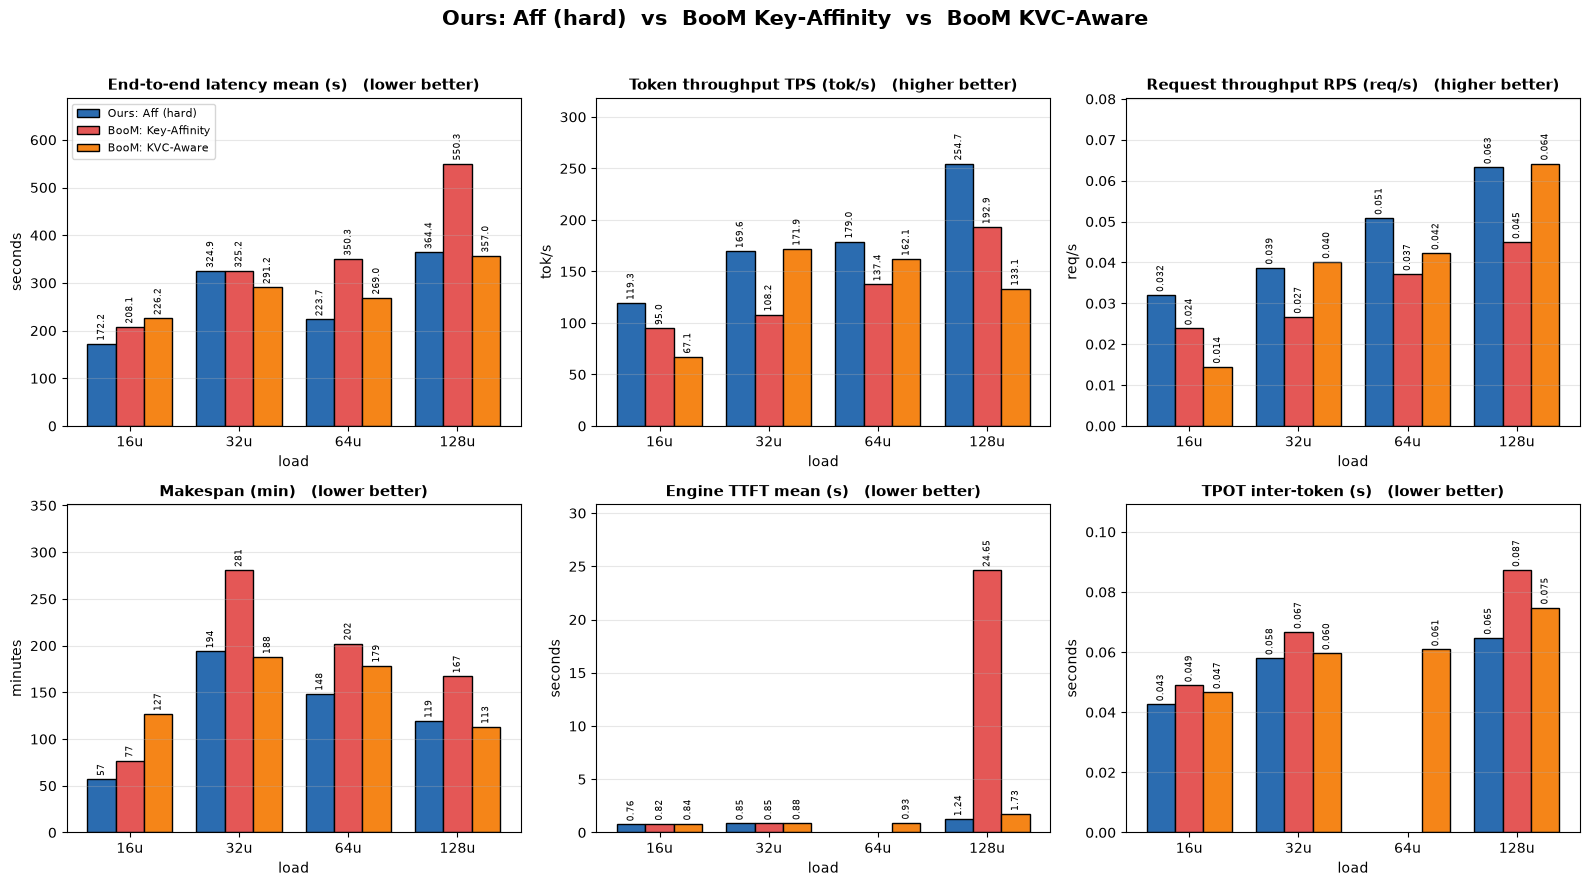

In [2]:
PANELS = [
    ("e2e_mean",     "End-to-end latency mean (s)", "seconds", False, "{:.1f}"),
    ("tps",          "Token throughput TPS (tok/s)", "tok/s",  True,  "{:.1f}"),
    ("rps",          "Request throughput RPS (req/s)", "req/s", True, "{:.3f}"),
    ("makespan_min", "Makespan (min)",              "minutes", False, "{:.0f}"),
    ("ttft_mean",    "Engine TTFT mean (s)",        "seconds", False, "{:.2f}"),
    ("tpot",         "TPOT inter-token (s)",        "seconds", False, "{:.3f}"),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
w = 0.26
for ax, (col, title, unit, hb, vf) in zip(axes.ravel(), PANELS):
    x = np.arange(len(USERS))
    allv = []
    for j, s in enumerate(STRATS):
        ys = [D[(D.strategy == s) & (D.users == u)][col].iloc[0] for u in USERS]
        allv += [v for v in ys if pd.notna(v)]
        ax.bar(x + (j - 1) * w, ys, w, color=COLOR[s], edgecolor="black", label=PRETTY[s])
    ymax = max(allv) if allv else 1.0
    for j, s in enumerate(STRATS):
        for i, u in enumerate(USERS):
            v = D[(D.strategy == s) & (D.users == u)][col].iloc[0]
            if pd.notna(v):
                ax.text(i + (j - 1) * w, v + ymax * 0.012, vf.format(v),
                        ha="center", va="bottom", fontsize=6.5, rotation=90)
    ax.set_title(title + ("   (higher better)" if hb else "   (lower better)"),
                 fontsize=11, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels([f"{u}u" for u in USERS])
    ax.set_ylabel(unit); ax.set_xlabel("load"); ax.grid(axis="y", alpha=.3)
    ax.set_ylim(0, ymax * 1.25)
axes.ravel()[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Ours: Aff (hard)  vs  BooM Key-Affinity  vs  BooM KVC-Aware",
             fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


## 3. How much Aff (hard) wins by

Percent by which **Aff (hard)** beats each BooM policy, per metric and load (green = Ours ahead,
red = behind). Positive is always "Ours better".

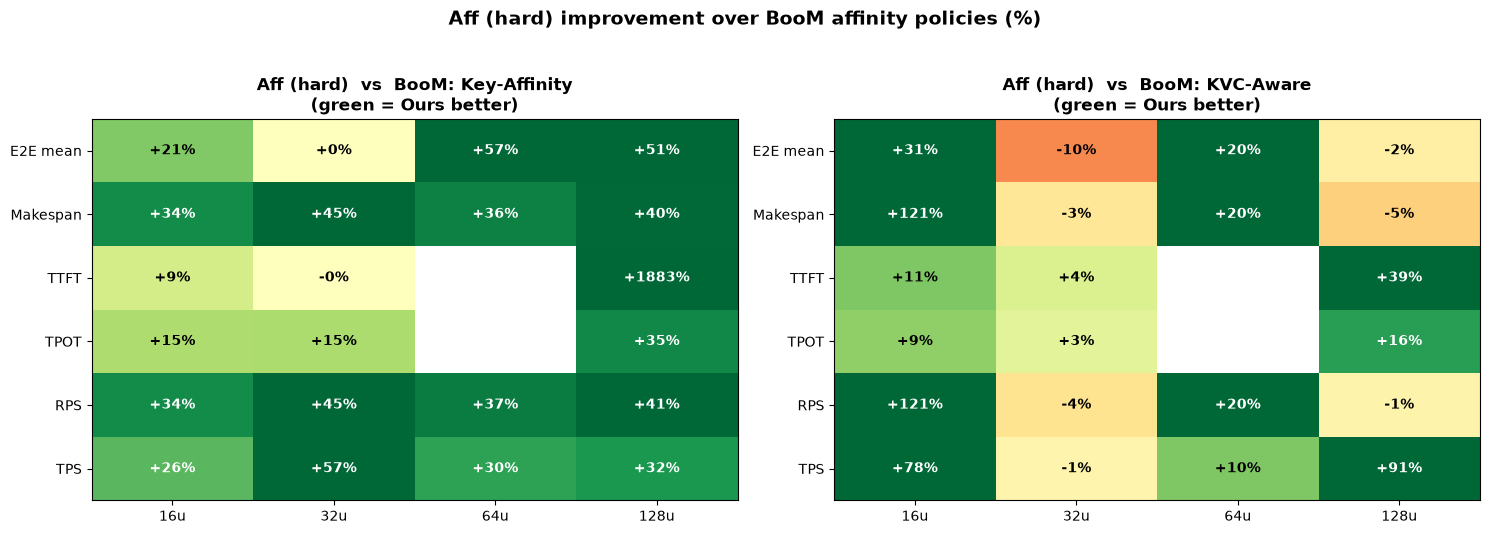

In [3]:
IMP = [("e2e_mean", "E2E mean", False), ("makespan_min", "Makespan", False),
       ("ttft_mean", "TTFT", False), ("tpot", "TPOT", False),
       ("rps", "RPS", True), ("tps", "TPS", True)]
def improve(a, b, hb):
    if pd.isna(a) or pd.isna(b): return np.nan
    return (a / b - 1) * 100 if hb else (b / a - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))
for ax, boom in zip(axes, ["key_aff", "kvc"]):
    M = np.full((len(IMP), len(USERS)), np.nan)
    for r, (col, _, hb) in enumerate(IMP):
        for c, u in enumerate(USERS):
            a = D[(D.strategy == "aff-hard") & (D.users == u)][col].iloc[0]
            b = D[(D.strategy == boom) & (D.users == u)][col].iloc[0]
            M[r, c] = improve(a, b, hb)
    # robust color scale so a single extreme cell (e.g. key_aff TTFT collapse)
    # doesn't wash out the rest; true % is still printed in each cell.
    absv = np.abs(M[~np.isnan(M)])
    vlim = max(float(np.nanpercentile(absv, 70)) if absv.size else 20.0, 20.0)
    im = ax.imshow(M, cmap="RdYlGn", vmin=-vlim, vmax=vlim, aspect="auto")
    ax.set_xticks(range(len(USERS))); ax.set_xticklabels([f"{u}u" for u in USERS])
    ax.set_yticks(range(len(IMP))); ax.set_yticklabels([lbl for _, lbl, _ in IMP])
    for r in range(len(IMP)):
        for c in range(len(USERS)):
            if pd.notna(M[r, c]):
                ax.text(c, r, f"{M[r, c]:+.0f}%", ha="center", va="center",
                        fontsize=10, fontweight="bold",
                        color=("black" if abs(M[r, c]) < 0.6 * vlim else "white"))
    ax.set_title(f"Aff (hard)  vs  {PRETTY[boom]}\n(green = Ours better)",
                 fontsize=12, fontweight="bold")
fig.suptitle("Aff (hard) improvement over BooM affinity policies (%)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()


## 4. Overall score across load (normalized within this 3-way set)

Overall = mean of the normalized TTFT / TPOT / E2E / RPS / TPS scores (1.0 = best of these three
at that load; TTFT/TPOT skipped where missing).

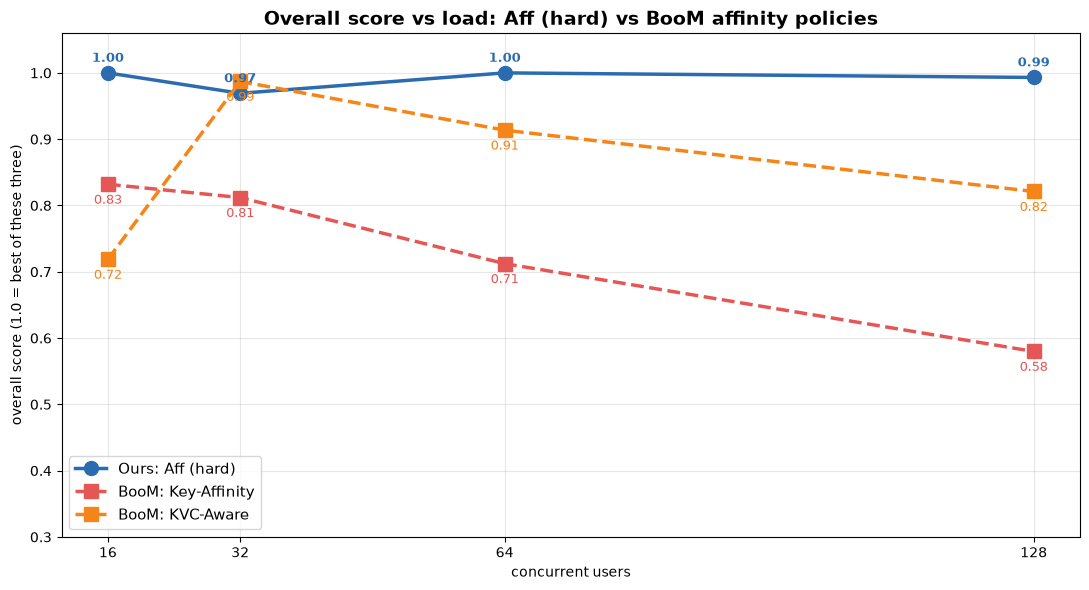

overall score (normalized within the 3 methods):
    16u: aff-hard 1.000 | key_aff 0.832 | kvc 0.719   -> beats both
    32u: aff-hard 0.969 | key_aff 0.812 | kvc 0.987   -> loses to kvc
    64u: aff-hard 1.000 | key_aff 0.712 | kvc 0.914   -> beats both
   128u: aff-hard 0.993 | key_aff 0.580 | kvc 0.821   -> beats both


In [4]:
SC_METRICS = [("ttft_mean", False), ("tpot", False), ("e2e_mean", False),
              ("rps", True), ("tps", True)]
SCORE = {u: {} for u in USERS}
for u in USERS:
    per = {s: [] for s in STRATS}
    for col, hb in SC_METRICS:
        vals = {s: D[(D.strategy == s) & (D.users == u)][col].iloc[0] for s in STRATS}
        vals = {s: v for s, v in vals.items() if pd.notna(v)}
        if not vals: continue
        m = max(vals.values()) if hb else min(vals.values())
        for s, v in vals.items():
            per[s].append(v / m if hb else m / v)
    for s in STRATS:
        SCORE[u][s] = float(np.mean(per[s])) if per[s] else np.nan

fig, ax = plt.subplots(figsize=(11, 6))
for s in STRATS:
    ys = [SCORE[u][s] for u in USERS]
    ax.plot(USERS, ys, "-o" if is_ours(s) else "--s", color=COLOR[s], lw=2.5,
            ms=10, label=PRETTY[s])
    for x, y in zip(USERS, ys):
        if pd.notna(y):
            ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                        xytext=(0, 8 if is_ours(s) else -14), ha="center", fontsize=9,
                        fontweight=("bold" if is_ours(s) else "normal"), color=COLOR[s])
ax.set_xticks(USERS); ax.set_ylim(0.3, 1.06)
ax.set_xlabel("concurrent users"); ax.set_ylabel("overall score (1.0 = best of these three)")
ax.set_title("Overall score vs load: Aff (hard) vs BooM affinity policies",
             fontsize=14, fontweight="bold")
ax.grid(alpha=.3); ax.legend(fontsize=11, loc="lower left")
plt.tight_layout(); plt.show()

print("overall score (normalized within the 3 methods):")
for u in USERS:
    a, k, v = SCORE[u]["aff-hard"], SCORE[u]["key_aff"], SCORE[u]["kvc"]
    win = "beats both" if (a >= k and a >= v) else ("loses to kvc" if v > a else "loses to key_aff")
    print(f"  {u:>4}u: aff-hard {a:.3f} | key_aff {k:.3f} | kvc {v:.3f}   -> {win}")
